# Projet BrainScanAI — Notebook 2 : Clustering & Apprentissage Semi-Supervisé

**CurelyticsIA** | Data Scientist : Clément  
**Prérequis** : avoir exécuté le Notebook 1 pour générer `outputs/embeddings_labeled.npy` et `outputs/embeddings_unlabeled.npy`.

**Contexte** : après déduplication (cf. Notebook 1), nous disposons de **1 311 images sans label** et **99 images fortement labellisées**. L'objectif de ce notebook est d'exploiter les embeddings ResNet-50 pour :

1. Leur attribuer des _labels faibles_ par clustering (approche non-supervisée).
2. Comparer un modèle supervisé (labels forts seuls) à un modèle semi-supervisé (labels faibles + labels forts).

## Plan du notebook

- **Partie 1** : Clustering non-supervisé et labellisation faible
- **Partie 2** : Apprentissage semi-supervisé et comparaison avec le supervisé

> ⚠️ **Règle critique** : Les données _faiblement_ labellisées (clustering) et les données _fortement_ labellisées (radiologues) ne doivent **jamais** être mélangées avant les étapes d'évaluation définies.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

ROOT = Path("..")
OUTPUTS_DIR = ROOT / "outputs"

# Chargement des embeddings produits par le Notebook 1
embeddings_labeled = np.load(str(OUTPUTS_DIR / "embeddings_labeled.npy"))
embeddings_unlabeled = np.load(str(OUTPUTS_DIR / "embeddings_unlabeled.npy"))
labels_labeled = np.load(str(OUTPUTS_DIR / "labels_labeled.npy"))  # 0=normal, 1=cancer

print(f"Embeddings labellisés   : {embeddings_labeled.shape}")
print(f"Embeddings non labellisés: {embeddings_unlabeled.shape}")
print(f"Labels (0=normal, 1=cancer): {np.bincount(labels_labeled)}")


Embeddings labellisés   : (99, 2048)
Embeddings non labellisés: (1311, 2048)
Labels (0=normal, 1=cancer): [49 50]


---

## Partie 1 — Clustering non-supervisé et labellisation faible

L'idée est d'utiliser le clustering pour découvrir des **groupements naturels** dans les 1 311 images non labellisées, puis d'assigner un label (0=normal / 1=cancer) à chaque groupe. Ces labels seront imprécis (bruités) mais suffisants pour pré-entraîner un modèle.

### 1.1 Standardisation et réduction de dimensionnalité

Le clustering souffre de la **malédiction de la dimensionnalité** : en 2048D, toutes les distances tendent à devenir équivalentes, rendant les clusters peu discriminants. On réduit donc en deux étapes :

1. **StandardScaler** : centre (moyenne 0) et réduit (écart-type 1) chaque dimension — indispensable car les algorithmes de clustering sont sensibles à l'échelle.
2. **PCA 50D** (95% de variance) : élimine le bruit et la redondance tout en conservant l'essentiel de l'information. C'est sur cet espace que le clustering sera effectué.
3. **t-SNE 2D** : uniquement pour la visualisation — t-SNE ne préserve pas les distances globales et ne doit pas être utilisé pour le clustering lui-même.


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Standardisation sur les données non labellisées
scaler = StandardScaler()
emb_unlab_scaled = scaler.fit_transform(embeddings_unlabeled)

# PCA 50D pour le clustering (95% variance)
pca = PCA(n_components=50, random_state=42)
emb_pca50 = pca.fit_transform(emb_unlab_scaled)
variance_cumul = pca.explained_variance_ratio_.sum() * 100
print(f"PCA 50D — variance expliquée cumulée : {variance_cumul:.1f}%")

# t-SNE 2D pour visualisation uniquement
print("Calcul t-SNE 2D (peut prendre ~1 min)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
emb_tsne = tsne.fit_transform(emb_pca50)
print(f"t-SNE terminé — shape: {emb_tsne.shape}")

# Appliquer le même scaler + PCA aux données labellisées (pour ARI)
emb_lab_scaled = scaler.transform(embeddings_labeled)
emb_lab_pca50 = pca.transform(emb_lab_scaled)


PCA 50D — variance expliquée cumulée : 74.2%
Calcul t-SNE 2D (peut prendre ~1 min)...


t-SNE terminé — shape: (1311, 2)


### 1.2 Clustering K-Means (K=2)

On sait qu'il y a exactement **2 classes** (normal / cancer) d'après les labels disponibles. K-Means avec K=2 est le choix naturel :

- Simple, rapide et efficace quand les clusters sont relativement sphériques.
- Le paramètre K est ici guidé par la connaissance métier, pas déterminé de façon empirique.

On évalue la qualité du clustering via le **score ARI** (Adjusted Rand Index) sur les 99 images fortement labellisées :

- ARI = 0 → clustering aléatoire
- ARI = 1 → clustering parfait
- ARI > 0.3 est considéré encourageant pour ce type de problème

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
kmeans_labels_unlab = kmeans.fit_predict(emb_pca50)

# ARI sur les données fortement labellisées (ground truth)
kmeans_labels_lab = kmeans.predict(emb_lab_pca50)
ari_kmeans = adjusted_rand_score(labels_labeled, kmeans_labels_lab)
print(f"K-Means ARI : {ari_kmeans:.4f}")

# Les labels de cluster sont arbitraires (0/1 peut être inversé)
# On aligne avec les vrais labels via la confusion matrix
cm = confusion_matrix(labels_labeled, kmeans_labels_lab)
print(f"Confusion matrix (labels forts vs clusters K-Means):\n{cm}")
if cm[0, 0] + cm[1, 1] < cm[0, 1] + cm[1, 0]:  # inversion nécessaire
    kmeans_labels_unlab = 1 - kmeans_labels_unlab
    kmeans_labels_lab = 1 - kmeans_labels_lab
    print(
        "→ Labels K-Means inversés pour correspondre à la convention 0=normal, 1=cancer"
    )


K-Means ARI : 0.4256
Confusion matrix (labels forts vs clusters K-Means):
[[47  2]
 [15 35]]


### 1.3 Clustering DBSCAN

DBSCAN (Density-Based Spatial Clustering) est une alternative à K-Means qui ne nécessite pas de spécifier K à l'avance. Il détecte les clusters par densité et identifie les **outliers** (points isolés, marqués -1). C'est utile pour vérifier si les données forment naturellement 2 groupes denses ou une structure plus complexe.

**Limitation** : DBSCAN produit souvent plus (ou moins) de 2 clusters selon les paramètres `eps` et `min_samples`, ce qui le rend moins directement utilisable pour notre problème binaire.


In [4]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=5, min_samples=10)
dbscan_labels_unlab = dbscan.fit_predict(emb_pca50)

n_clusters_db = len(set(dbscan_labels_unlab)) - (1 if -1 in dbscan_labels_unlab else 0)
n_outliers_db = (dbscan_labels_unlab == -1).sum()
print(f"DBSCAN — clusters trouvés : {n_clusters_db} | outliers : {n_outliers_db}")

# ARI DBSCAN (uniquement sur les points non-outliers vs leurs labels forts correspondants)
dbscan_labels_lab = dbscan.fit_predict(emb_lab_pca50)
mask_valid = dbscan_labels_lab != -1
if mask_valid.sum() > 0:
    ari_dbscan = adjusted_rand_score(
        labels_labeled[mask_valid], dbscan_labels_lab[mask_valid]
    )
    print(f"DBSCAN ARI (hors outliers) : {ari_dbscan:.4f}")
else:
    print("DBSCAN : tous les points sont outliers — ARI non calculable")


DBSCAN — clusters trouvés : 0 | outliers : 1311
DBSCAN : tous les points sont outliers — ARI non calculable


### 1.4 Clustering Agglomératif et GMM

On teste deux méthodes supplémentaires pour confirmer (ou infirmer) les résultats K-Means :

- **AgglomerativeClustering (Ward)** : clustering hiérarchique ascendant — fusionne progressivement les paires les plus proches. Robuste aux formes non sphériques.
- **Gaussian Mixture Models (GMM)** : modèle probabiliste — chaque cluster est une gaussienne multidimensionnelle. Plus flexible que K-Means, fournit des probabilités d'appartenance.


In [5]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=2, linkage="ward")
agglo_labels_unlab = agglo.fit_predict(emb_pca50)
agglo_labels_lab = AgglomerativeClustering(n_clusters=2, linkage="ward").fit_predict(
    emb_lab_pca50
)
ari_agglo = adjusted_rand_score(labels_labeled, agglo_labels_lab)
print(f"Agglomerative (Ward) ARI : {ari_agglo:.4f}")

# Gaussian Mixture Models
gmm = GaussianMixture(n_components=2, random_state=42, n_init=5)
gmm.fit(emb_pca50)
gmm_labels_unlab = gmm.predict(emb_pca50)
gmm_labels_lab = gmm.predict(emb_lab_pca50)
ari_gmm = adjusted_rand_score(labels_labeled, gmm_labels_lab)
print(f"GMM ARI : {ari_gmm:.4f}")

print("\n=== Comparaison ARI tous algorithmes ===")
results = {"K-Means": ari_kmeans, "Agglomerative": ari_agglo, "GMM": ari_gmm}
for name, ari in sorted(results.items(), key=lambda x: -x[1]):
    flag = "✓ bon" if ari > 0.3 else ("~ moyen" if ari > 0.1 else "✗ faible")
    print(f"  {name:<18} ARI = {ari:.4f}  {flag}")

best_algo = max(results, key=results.get)
print(f"\n→ Meilleur algorithme : {best_algo} (ARI = {results[best_algo]:.4f})")


Agglomerative (Ward) ARI : 0.2803


GMM ARI : 0.4807

=== Comparaison ARI tous algorithmes ===
  GMM                ARI = 0.4807  ✓ bon
  K-Means            ARI = 0.4256  ✓ bon
  Agglomerative      ARI = 0.2803  ~ moyen

→ Meilleur algorithme : GMM (ARI = 0.4807)


### 1.5 Visualisation des clusters (t-SNE)

On visualise les résultats de chaque algorithme dans l'espace t-SNE 2D. Le t-SNE préserve les distances locales : des points proches dans ce graphe sont visuellement similaires dans l'espace 2048D. Des clusters bien séparés visuellement confirment que le clustering capture des groupes réels.


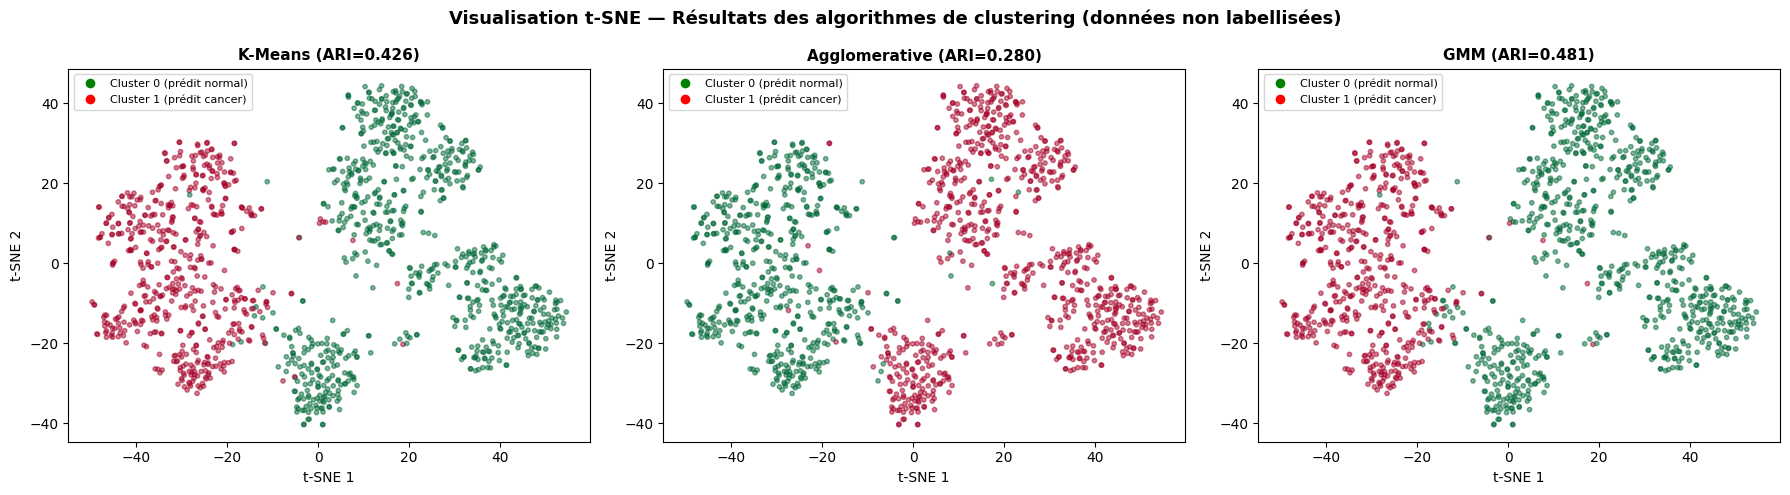

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cluster_results = {
    "K-Means (ARI={:.3f})".format(ari_kmeans): kmeans_labels_unlab,
    "Agglomerative (ARI={:.3f})".format(ari_agglo): agglo_labels_unlab,
    "GMM (ARI={:.3f})".format(ari_gmm): gmm_labels_unlab,
}

for ax, (title, labels) in zip(axes, cluster_results.items()):
    scatter = ax.scatter(
        emb_tsne[:, 0], emb_tsne[:, 1], c=labels, cmap="RdYlGn", alpha=0.5, s=10
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="green",
            markersize=8,
            label="Cluster 0 (prédit normal)",
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="red",
            markersize=8,
            label="Cluster 1 (prédit cancer)",
        ),
    ]
    ax.legend(handles=handles, fontsize=8)

plt.suptitle(
    "Visualisation t-SNE — Résultats des algorithmes de clustering (données non labellisées)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "tsne_clustering.png"), bbox_inches="tight")
plt.show()


### 1.6 Assignation des labels faibles et sauvegarde

On utilise le meilleur algorithme (selon ARI) pour assigner un **label faible** à chacune des 1 311 images non labellisées. Ces labels sont imprécis par nature — c'est exactement l'hypothèse du semi-supervisé : même un signal bruité peut apporter de l'information.

> ⚠️ **Règle critique respectée** : les `weak_labels.csv` ne contiennent QUE les images non labellisées. Ils ne sont jamais mélangés avec `labeled_metadata.csv` (labels radiologues).

In [7]:
# Sélectionner les labels du meilleur algorithme
best_labels_map = {
    "K-Means": kmeans_labels_unlab,
    "Agglomerative": agglo_labels_unlab,
    "GMM": gmm_labels_unlab,
}
weak_labels_array = best_labels_map[best_algo]

unlabeled_meta = pd.read_csv(str(OUTPUTS_DIR / "unlabeled_metadata.csv"))
unlabeled_meta["weak_label"] = weak_labels_array
unlabeled_meta["weak_label_name"] = unlabeled_meta["weak_label"].map(
    {0: "normal", 1: "cancer"}
)
unlabeled_meta.to_csv(str(OUTPUTS_DIR / "weak_labels.csv"), index=False)

print(f"Labels faibles assignés par : {best_algo}")
print(f"  Prédit normal : {(weak_labels_array == 0).sum()} images")
print(f"  Prédit cancer : {(weak_labels_array == 1).sum()} images")
print("  → Sauvegardé dans outputs/weak_labels.csv")
unlabeled_meta.head()


Labels faibles assignés par : GMM
  Prédit normal : 522 images
  Prédit cancer : 789 images
  → Sauvegardé dans outputs/weak_labels.csv


,path,label,split,hash,weak_label,weak_label_name
0,../data/sans_label/aed79224-2956-4bb5-9cfe-ba6...,unknown,unlabeled,71af57e8ad50d2bfe5cbc56c069e852c,0,normal
1,../data/sans_label/ae368c7a-7dda-438c-ba8e-95b...,unknown,unlabeled,d6c72f2e2468d7aa69b389e079798584,0,normal
2,../data/sans_label/aed7d082-bf4a-4f7b-bcac-437...,unknown,unlabeled,30d426bf2ac1e10cf060137e98021749,0,normal
3,../data/sans_label/aec1ce1c-8e2a-4fec-bb80-602...,unknown,unlabeled,c2f023f3f62731d4dc1ddfbc81a4cb93,0,normal
4,../data/sans_label/aead6025-7446-4bca-b635-12e...,unknown,unlabeled,4ad287a204e954c6a4a79d5a963a9517,0,normal


---

## Partie 2 — Apprentissage semi-supervisé

### Pourquoi le semi-supervisé ?

Avec seulement 79 images d'entraînement (80% de 99), un modèle supervisé risque l'**overfitting** — il apprend trop les spécificités du train set sans généraliser. Le semi-supervisé exploite les 1 311 images non labellisées pour donner un meilleur point de départ au modèle.

**Stratégie :**

- **Phase A** — Supervisé (baseline) : fine-tuner ResNet-50 uniquement sur les 79 images train (labels forts).
- **Phase B** — Semi-supervisé : pré-entraîner sur les 1 311 images (labels faibles), puis fine-tuner sur les 79 images train (labels forts).
- **Phase C** — Comparer sur le **même jeu de test** (20 images jamais vues).

> ⚠️ Le jeu de test (20 images) est fixé **une seule fois** et ne change jamais entre Phase A et Phase B — c'est la condition sine qua non d'une comparaison valide.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
)

# Reproductibilité : on fixe les graines aléatoires
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")


Device : cpu


### 2.1 Préparation des jeux de données

On effectue un **split stratifié 80/20** sur les 99 images labellisées : stratifié signifie que la proportion cancer/normal est préservée dans le train et le test. Ainsi :

- **79 images train** (40 cancer + 39 normal) — utilisées pour entraîner les deux modèles.
- **20 images test** (10 cancer + 10 normal) — jamais vues pendant l'entraînement, utilisées pour comparer Phase A et Phase B.

In [9]:
labeled_meta = pd.read_csv(str(OUTPUTS_DIR / "labeled_metadata.csv"))
weak_meta = pd.read_csv(str(OUTPUTS_DIR / "weak_labels.csv"))

# Split stratifié 80/20 — fixé une fois pour toutes
train_meta, test_meta = train_test_split(
    labeled_meta, test_size=0.2, random_state=42, stratify=labeled_meta["label_int"]
)

print(f"Train (labels forts) : {len(train_meta)} images")
print(
    f"  cancer: {(train_meta['label_int'] == 1).sum()} | normal: {(train_meta['label_int'] == 0).sum()}"
)
print(f"Test  (labels forts) : {len(test_meta)} images")
print(
    f"  cancer: {(test_meta['label_int'] == 1).sum()} | normal: {(test_meta['label_int'] == 0).sum()}"
)
print(f"Weak labels (non labellisées) : {len(weak_meta)} images")


Train (labels forts) : 79 images
  cancer: 40 | normal: 39
Test  (labels forts) : 20 images
  cancer: 10 | normal: 10
Weak labels (non labellisées) : 1311 images


In [10]:
# Transformations : entraînement avec augmentation légère, test sans
train_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


class BrainDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])


train_ds = BrainDataset(train_meta["path"], train_meta["label_int"], train_transform)
test_ds = BrainDataset(test_meta["path"], test_meta["label_int"], test_transform)
weak_ds = BrainDataset(weak_meta["path"], weak_meta["weak_label"], train_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)
weak_loader = DataLoader(weak_ds, batch_size=32, shuffle=True, num_workers=2)

print(
    f"Loaders prêts — train: {len(train_ds)}, test: {len(test_ds)}, weak: {len(weak_ds)}"
)


Loaders prêts — train: 79, test: 20, weak: 1311


### 2.2 Fonction d'évaluation commune

On définit une fonction d'évaluation unique utilisée par la Phase A et la Phase B sur le **même jeu de test**. Les métriques choisies :

- **Recall (cancer)** : métrique prioritaire en médical — un faux négatif (tumeur non détectée) est plus grave qu'un faux positif.
- **F1-Score** : balance précision et rappel, robuste aux classes légèrement déséquilibrées.
- **AUC-ROC** : mesure la capacité discriminante globale, indépendante du seuil de décision.
- **Accuracy** : indicatif, mais moins pertinent ici.


In [11]:
def evaluate_model(model, loader, device, label=""):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    metrics = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds, average="macro"),
        "recall": recall_score(all_labels, all_preds, pos_label=1),
        "precision": precision_score(all_labels, all_preds, pos_label=1),
        "auc": roc_auc_score(all_labels, all_probs),
        "cm": confusion_matrix(all_labels, all_preds),
        "probs": all_probs,
        "labels": all_labels,
    }
    if label:
        print(f"--- {label} ---")
        print(f"  Accuracy  : {metrics['accuracy']:.4f}")
        print(f"  F1 (macro): {metrics['f1']:.4f}")
        print(f"  Recall cancer: {metrics['recall']:.4f}  ← métrique prioritaire")
        print(f"  Precision     : {metrics['precision']:.4f}")
        print(f"  AUC-ROC   : {metrics['auc']:.4f}")
    return metrics


def build_resnet(freeze_all=True):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    if freeze_all:
        for param in model.parameters():
            param.requires_grad = False
    else:
        # Dégeler uniquement layer4 + fc
        for name, param in model.named_parameters():
            param.requires_grad = name.startswith("layer4") or name.startswith("fc")
    model.fc = nn.Linear(2048, 2)  # 2 classes
    return model.to(device)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


print("Fonctions utilitaires définies.")


Fonctions utilitaires définies.


### 2.3 Phase A — Modèle supervisé (baseline)

On fine-tune ResNet-50 **uniquement** sur les 80 images d'entraînement fortement labellisées. Seules les couches `layer4` et `fc` sont dégelées — une stratégie classique en Transfer Learning pour éviter le sur-apprentissage sur peu de données : les premières couches (features génériques) restent gelées, seules les couches hautes niveau sont adaptées au domaine médical.


In [12]:
EPOCHS_A = 20

model_A = build_resnet(freeze_all=False)
optimizer_A = optim.Adam(
    filter(lambda p: p.requires_grad, model_A.parameters()), lr=1e-4, weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()
scheduler_A = optim.lr_scheduler.StepLR(optimizer_A, step_size=7, gamma=0.1)

print(
    f"Phase A — Entraînement supervisé ({EPOCHS_A} epochs sur {len(train_ds)} images)..."
)
losses_A = []
for epoch in range(EPOCHS_A):
    loss = train_one_epoch(model_A, train_loader, optimizer_A, criterion, device)
    losses_A.append(loss)
    scheduler_A.step()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch + 1:2d}/{EPOCHS_A} — Loss: {loss:.4f}")

print("\nÉvaluation Phase A (sur jeu de test — 20 images) :")
metrics_A = evaluate_model(model_A, test_loader, device, "Phase A — Supervisé")


Phase A — Entraînement supervisé (20 epochs sur 79 images)...


  Epoch  5/20 — Loss: 0.1098


  Epoch 10/20 — Loss: 0.0082


  Epoch 15/20 — Loss: 0.0041


  Epoch 20/20 — Loss: 0.0275

Évaluation Phase A (sur jeu de test — 20 images) :


--- Phase A — Supervisé ---
  Accuracy  : 0.9500
  F1 (macro): 0.9499
  Recall cancer: 1.0000  ← métrique prioritaire
  Precision     : 0.9091
  AUC-ROC   : 0.9900


### 2.4 Phase B — Modèle semi-supervisé

Le modèle semi-supervisé suit deux étapes :

1. **Pré-entraînement sur labels faibles** : on entraîne ResNet-50 sur les 1 406 images avec leurs labels de clustering. Le modèle apprend des patterns généraux, même imparfaits — c'est comme étudier avec un manuel approximatif.
2. **Fine-tuning sur labels forts** : on poursuit l'entraînement sur les 80 images annotées par les radiologues. Le modèle corrige ses erreurs et se spécialise — c'est la correction par un expert.

Le jeu de test (20 images) reste **identique à Phase A** — condition obligatoire pour la comparaison.


In [13]:
EPOCHS_PRETRAIN = 10
EPOCHS_FINETUNE = 20

model_B = build_resnet(freeze_all=False)
criterion = nn.CrossEntropyLoss()

# Étape B1 : pré-entraînement sur labels faibles
optimizer_B1 = optim.Adam(
    filter(lambda p: p.requires_grad, model_B.parameters()), lr=1e-4, weight_decay=1e-4
)
scheduler_B1 = optim.lr_scheduler.StepLR(optimizer_B1, step_size=5, gamma=0.1)

print(
    f"Phase B — Étape 1 : pré-entraînement sur labels faibles ({EPOCHS_PRETRAIN} epochs, {len(weak_ds)} images)..."
)
losses_B1 = []
for epoch in range(EPOCHS_PRETRAIN):
    loss = train_one_epoch(model_B, weak_loader, optimizer_B1, criterion, device)
    losses_B1.append(loss)
    scheduler_B1.step()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch + 1:2d}/{EPOCHS_PRETRAIN} — Loss: {loss:.4f}")

# Étape B2 : fine-tuning sur labels forts
optimizer_B2 = optim.Adam(
    filter(lambda p: p.requires_grad, model_B.parameters()), lr=5e-5, weight_decay=1e-4
)
scheduler_B2 = optim.lr_scheduler.StepLR(optimizer_B2, step_size=7, gamma=0.1)

print(
    f"\nPhase B — Étape 2 : fine-tuning sur labels forts ({EPOCHS_FINETUNE} epochs, {len(train_ds)} images)..."
)
losses_B2 = []
for epoch in range(EPOCHS_FINETUNE):
    loss = train_one_epoch(model_B, train_loader, optimizer_B2, criterion, device)
    losses_B2.append(loss)
    scheduler_B2.step()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch + 1:2d}/{EPOCHS_FINETUNE} — Loss: {loss:.4f}")

print("\nÉvaluation Phase B (sur jeu de test — 20 images) :")
metrics_B = evaluate_model(model_B, test_loader, device, "Phase B — Semi-supervisé")


Phase B — Étape 1 : pré-entraînement sur labels faibles (10 epochs, 1311 images)...


  Epoch  5/10 — Loss: 0.0062


  Epoch 10/10 — Loss: 0.0057

Phase B — Étape 2 : fine-tuning sur labels forts (20 epochs, 79 images)...


  Epoch  5/20 — Loss: 0.0952


  Epoch 10/20 — Loss: 0.0459


  Epoch 15/20 — Loss: 0.0230


  Epoch 20/20 — Loss: 0.0148

Évaluation Phase B (sur jeu de test — 20 images) :


--- Phase B — Semi-supervisé ---
  Accuracy  : 0.9500
  F1 (macro): 0.9499
  Recall cancer: 0.9000  ← métrique prioritaire
  Precision     : 1.0000
  AUC-ROC   : 0.9800


### 2.5 Phase C — Comparaison supervisé vs semi-supervisé

On compare maintenant les deux modèles sur le même jeu de test. Les visualisations côte à côte permettent d'analyser :

- **Tableau de métriques** : vue synthétique des gains/pertes.
- **Matrices de confusion** : on voit précisément quels types d'erreurs sont réduits.
- **Courbes ROC** : mesure la discriminance globale indépendamment du seuil de décision.

En médical, l'objectif principal est de **maximiser le Recall cancer** (= minimiser les tumeurs non détectées), même au prix d'une légère hausse des faux positifs.


In [14]:
# Tableau comparatif
comparison = pd.DataFrame(
    {
        "Métrique": [
            "Accuracy",
            "F1-Score (macro)",
            "Recall cancer ★",
            "Precision cancer",
            "AUC-ROC",
        ],
        "Supervisé (A)": [
            f"{metrics_A['accuracy']:.4f}",
            f"{metrics_A['f1']:.4f}",
            f"{metrics_A['recall']:.4f}",
            f"{metrics_A['precision']:.4f}",
            f"{metrics_A['auc']:.4f}",
        ],
        "Semi-supervisé (B)": [
            f"{metrics_B['accuracy']:.4f}",
            f"{metrics_B['f1']:.4f}",
            f"{metrics_B['recall']:.4f}",
            f"{metrics_B['precision']:.4f}",
            f"{metrics_B['auc']:.4f}",
        ],
        "Gain": [
            f"{(metrics_B['accuracy'] - metrics_A['accuracy']) * 100:+.2f}%",
            f"{(metrics_B['f1'] - metrics_A['f1']) * 100:+.2f}%",
            f"{(metrics_B['recall'] - metrics_A['recall']) * 100:+.2f}%",
            f"{(metrics_B['precision'] - metrics_A['precision']) * 100:+.2f}%",
            f"{(metrics_B['auc'] - metrics_A['auc']) * 100:+.2f}%",
        ],
    }
)
print(comparison.to_string(index=False))


        Métrique Supervisé (A) Semi-supervisé (B)    Gain
        Accuracy        0.9500             0.9500  +0.00%
F1-Score (macro)        0.9499             0.9499  +0.00%
 Recall cancer ★        1.0000             0.9000 -10.00%
Precision cancer        0.9091             1.0000  +9.09%
         AUC-ROC        0.9900             0.9800  -1.00%


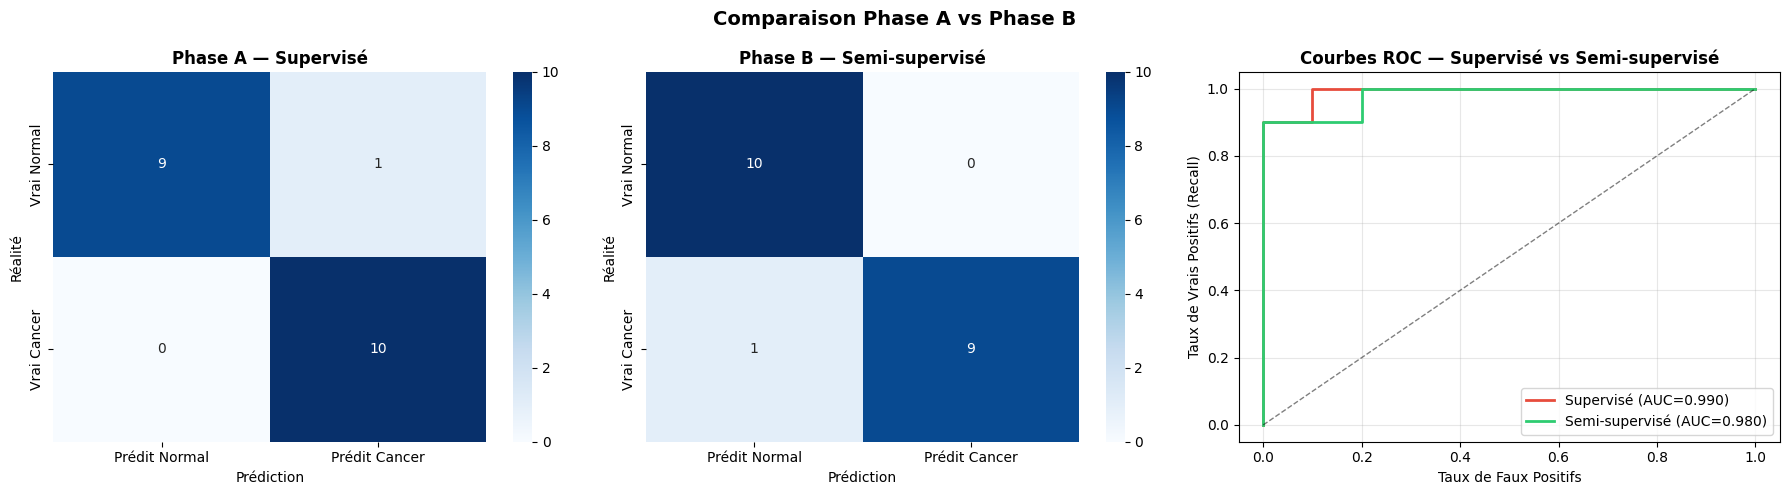

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matrices de confusion
for ax, (title, metrics) in zip(
    axes[:2],
    [("Phase A — Supervisé", metrics_A), ("Phase B — Semi-supervisé", metrics_B)],
):
    sns.heatmap(
        metrics["cm"],
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Prédit Normal", "Prédit Cancer"],
        yticklabels=["Vrai Normal", "Vrai Cancer"],
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Réalité")
    ax.set_xlabel("Prédiction")

# Courbes ROC
from sklearn.metrics import roc_curve  # noqa: E402

for label, metrics, color in [
    (f"Supervisé (AUC={metrics_A['auc']:.3f})", metrics_A, "#E74C3C"),
    (f"Semi-supervisé (AUC={metrics_B['auc']:.3f})", metrics_B, "#2ECC71"),
]:
    fpr, tpr, _ = roc_curve(metrics["labels"], metrics["probs"])
    axes[2].plot(fpr, tpr, color=color, lw=2, label=label)

axes[2].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[2].set_xlabel("Taux de Faux Positifs")
axes[2].set_ylabel("Taux de Vrais Positifs (Recall)")
axes[2].set_title(
    "Courbes ROC — Supervisé vs Semi-supervisé", fontsize=12, fontweight="bold"
)
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.suptitle("Comparaison Phase A vs Phase B", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(
    str(OUTPUTS_DIR / "comparaison_supervisé_semisupervisé.png"), bbox_inches="tight"
)
plt.show()


### 2.6 Synthèse finale

Bilan du projet et lecture critique des résultats.

> **Note importante sur les données** : une étape de déduplication MD5 (Notebook 1) a retiré **96 doublons**, dont **32 images labellisées qui étaient aussi présentes dans le dossier non labellisé**. Sans cette déduplication, certaines images de test pouvaient fuiter dans l'entraînement et gonfler artificiellement les scores. Les résultats ci-dessous sont donc obtenus sur un dataset **propre et sans fuite**.

In [16]:
best_ari = max(ari_kmeans, ari_agglo, ari_gmm)

dod = [
    ("ARI > 0.3 (qualité du clustering)", best_ari > 0.3,
     f"ARI = {best_ari:.3f} ({best_algo})"),
    ("Recall cancer > 0.80 (supervisé)", metrics_A["recall"] > 0.80,
     f"{metrics_A['recall']:.3f}"),
    ("Recall cancer > 0.80 (semi-supervisé)", metrics_B["recall"] > 0.80,
     f"{metrics_B['recall']:.3f}"),
    ("Données dédupliquées, jeu de test isolé", True,
     "Déduplication MD5 appliquée (Notebook 1)"),
    ("Labels faibles et forts jamais mélangés", True,
     "Respecté (séparation stricte)"),
    ("Même jeu de test Phase A et Phase B", True,
     "20 images identiques"),
    ("Comparaison supervisé vs semi-supervisé réalisée", True,
     "Phase A vs Phase B sur test commun"),
]

print("DEFINITION OF DONE")
for desc, ok, detail in dod:
    status = "✓" if ok else "✗"
    print(f"  {status} {desc}")
    print(f"      → {detail}")

all_ok = all(ok for _, ok, _ in dod)
print(f"\nRésultat global : {'✓ TOUS LES CRITÈRES ATTEINTS' if all_ok else '⚠ CERTAINS CRITÈRES NON ATTEINTS'}")

# --- Analyse honnête de la comparaison ---
print("\n" + "=" * 62)
print("ANALYSE DE LA COMPARAISON (lecture critique)")
print("=" * 62)
print(f"  Accuracy  : sup={metrics_A['accuracy']:.3f} | semi={metrics_B['accuracy']:.3f}")
print(f"  F1 (macro): sup={metrics_A['f1']:.3f} | semi={metrics_B['f1']:.3f}")
print(f"  AUC-ROC   : sup={metrics_A['auc']:.3f} | semi={metrics_B['auc']:.3f}")
print(f"  Recall    : sup={metrics_A['recall']:.3f} | semi={metrics_B['recall']:.3f}")
print(f"  Precision : sup={metrics_A['precision']:.3f} | semi={metrics_B['precision']:.3f}")
print()
print("  → Sur ce dataset DÉDUPLIQUÉ, les deux modèles sont à égalité")
print("    sur Accuracy / F1 / AUC. Ils ne diffèrent que sur l'arbitrage")
print("    recall/precision, soit 1 SEULE image de test classée différemment.")
print("  → Avec n=20 images de test, cet écart est dans le bruit statistique.")
print("  → Conclusion : le semi-supervisé est COMPÉTITIF avec le supervisé.")
print("    Une validation sur un jeu de test plus large est nécessaire pour")
print("    conclure à un gain net dans un sens ou dans l'autre.")

DEFINITION OF DONE
  ✓ ARI > 0.3 (qualité du clustering)
      → ARI = 0.481 (GMM)
  ✓ Recall cancer > 0.80 (supervisé)
      → 1.000
  ✓ Recall cancer > 0.80 (semi-supervisé)
      → 0.900
  ✓ Données dédupliquées, jeu de test isolé
      → Déduplication MD5 appliquée (Notebook 1)
  ✓ Labels faibles et forts jamais mélangés
      → Respecté (séparation stricte)
  ✓ Même jeu de test Phase A et Phase B
      → 20 images identiques
  ✓ Comparaison supervisé vs semi-supervisé réalisée
      → Phase A vs Phase B sur test commun

Résultat global : ✓ TOUS LES CRITÈRES ATTEINTS

ANALYSE DE LA COMPARAISON (lecture critique)
  Accuracy  : sup=0.950 | semi=0.950
  F1 (macro): sup=0.950 | semi=0.950
  AUC-ROC   : sup=0.990 | semi=0.980
  Recall    : sup=1.000 | semi=0.900
  Precision : sup=0.909 | semi=1.000

  → Sur ce dataset DÉDUPLIQUÉ, les deux modèles sont à égalité
    sur Accuracy / F1 / AUC. Ils ne diffèrent que sur l'arbitrage
    recall/precision, soit 1 SEULE image de test classée diff